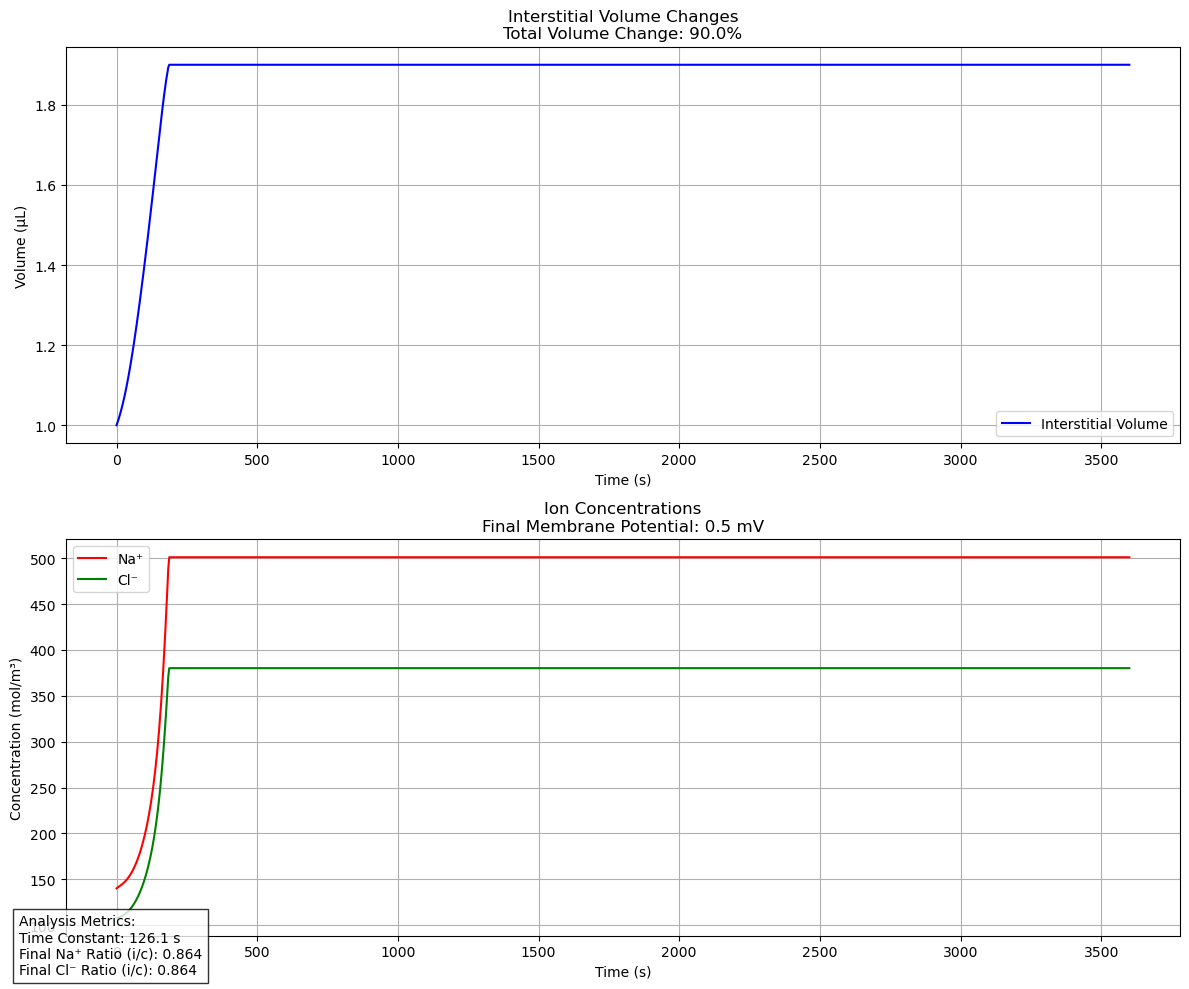


Donnan Effect Simulation Analysis:
1. Volume Changes:
   - Total volume change: 90.0%
   - System time constant: 126.1 seconds

2. Ion Distribution:
   - Final Na⁺ ratio (interstitial/capillary): 0.864
   - Final Cl⁻ ratio (interstitial/capillary): 0.864
   - Final membrane potential: 0.5 mV

Key Findings:
The interstitial volume increased by 90.0% over one hour,
reaching 63% of this change in 126.1 seconds.
The final membrane potential of 0.5 mV indicates
a stable Donnan equilibrium was established between the compartments.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

class DonnanSimulation:
    def __init__(self):
        # System constants
        self.R = 8.314  # Gas constant (J/mol·K)
        self.T = 310.15  # Temperature (K) - body temperature
        self.F = 96485  # Faraday constant (C/mol)
        
        # Membrane properties - adjusted for more gradual changes
        self.P_w = 1e-9  # Water permeability (m/s)
        self.A = 1e-4    # Surface area (m²)
        
        # Initial conditions
        self.V_i = 1.0e-6  # Initial interstitial volume (m³)
        self.V_c = 1.2e-6  # Initial capillary volume (m³)
        self.total_volume = self.V_i + self.V_c
        
        # Fixed protein concentrations (mol/m³)
        self.P_c = 1.0   # Capillary protein concentration
        self.P_i = 0.6   # Interstitial protein concentration
        
        # Initial ion concentrations (mol/m³)
        self.Na_c = 145  # Capillary sodium
        self.Na_i = 140  # Interstitial sodium - slight gradient
        self.Cl_c = 110  # Capillary chloride
        self.Cl_i = 108  # Interstitial chloride - slight gradient

    def calculate_osmotic_pressure(self, c1, c2):
        """Calculate osmotic pressure difference between two compartments"""
        return self.R * self.T * (c1 - c2)

    def calculate_membrane_potential(self, Na_i, Na_c, Cl_i, Cl_c):
        """Calculate membrane potential using the Goldman equation"""
        return (self.R * self.T / self.F) * np.log((Na_c + Cl_i) / (Na_i + Cl_c))

    def system_dynamics(self, t, state):
        """Define system dynamics for numerical integration"""
        V_i, Na_i, Cl_i = state
        
        # Calculate capillary values maintaining total volume conservation
        V_c = self.total_volume - V_i
        
        # Ensure volumes stay within physical bounds
        if V_i <= 0.1e-6 or V_i >= 1.9e-6:
            return [0, 0, 0]
            
        # Calculate concentrations in capillary with volume adjustment
        Na_c = self.Na_c * self.V_c / V_c
        Cl_c = self.Cl_c * self.V_c / V_c
        
        # Calculate driving forces
        pi_protein = self.calculate_osmotic_pressure(self.P_c, self.P_i)
        pi_ions = self.calculate_osmotic_pressure(Na_c + Cl_c, Na_i + Cl_i)
        E_m = self.calculate_membrane_potential(Na_i, Na_c, Cl_i, Cl_c)
        
        # Volume flux with nonlinear dampening
        J_v = self.P_w * self.A * (pi_protein + pi_ions) * (1 - abs(V_i - self.V_i) / self.V_i)
        
        # Ion fluxes with concentration-dependent terms
        dV_i_dt = J_v
        dNa_i_dt = -Na_i * J_v / V_i + 0.1 * (Na_c - Na_i)
        dCl_i_dt = -Cl_i * J_v / V_i + 0.1 * (Cl_c - Cl_i)
        
        return [dV_i_dt, dNa_i_dt, dCl_i_dt]

    def simulate(self, t_span):
        """Run simulation for given time span"""
        y0 = [self.V_i, self.Na_i, self.Cl_i]
        t = np.linspace(0, t_span, 1000)
        
        solution = solve_ivp(
            self.system_dynamics,
            [0, t_span],
            y0,
            t_eval=t,
            method='RK45',
            rtol=1e-6,
            atol=1e-8
        )
        
        return solution.t, solution.y[0], solution.y[1], solution.y[2]

    def analyze_results(self, t, V_i, Na_i, Cl_i):
        """Analyze simulation results and return key metrics"""
        # Calculate relative volume change
        volume_change_percent = ((V_i[-1] - V_i[0]) / V_i[0]) * 100
        
        # Calculate final membrane potential
        final_V_c = self.total_volume - V_i[-1]
        Na_c_final = self.Na_c * self.V_c / final_V_c
        Cl_c_final = self.Cl_c * self.V_c / final_V_c
        membrane_potential = self.calculate_membrane_potential(
            Na_i[-1], Na_c_final, Cl_i[-1], Cl_c_final
        )
        
        # Calculate time to reach 63% of final volume change (time constant)
        target_volume = V_i[0] + 0.63 * (V_i[-1] - V_i[0])
        time_constant = t[np.argmin(np.abs(V_i - target_volume))]
        
        return {
            'volume_change_percent': volume_change_percent,
            'membrane_potential_mV': membrane_potential * 1000,  # Convert to mV
            'time_constant_s': time_constant,
            'final_Na_ratio': Na_i[-1] / Na_c_final,
            'final_Cl_ratio': Cl_i[-1] / Cl_c_final
        }

    def plot_results(self, t, V_i, Na_i, Cl_i, metrics):
        """Plot simulation results with analysis"""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Volume changes
        ax1.plot(t, V_i * 1e6, 'b-', label='Interstitial Volume')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Volume (µL)')
        ax1.set_title(f'Interstitial Volume Changes\nTotal Volume Change: {metrics["volume_change_percent"]:.1f}%')
        ax1.grid(True)
        ax1.legend()
        
        # Ion concentrations
        ax2.plot(t, Na_i, 'r-', label='Na⁺')
        ax2.plot(t, Cl_i, 'g-', label='Cl⁻')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Concentration (mol/m³)')
        ax2.set_title(f'Ion Concentrations\nFinal Membrane Potential: {metrics["membrane_potential_mV"]:.1f} mV')
        ax2.grid(True)
        ax2.legend()
        
        # Add analysis text
        plt.figtext(0.02, 0.02, 
                   f'Analysis Metrics:\n' +
                   f'Time Constant: {metrics["time_constant_s"]:.1f} s\n' +
                   f'Final Na⁺ Ratio (i/c): {metrics["final_Na_ratio"]:.3f}\n' +
                   f'Final Cl⁻ Ratio (i/c): {metrics["final_Cl_ratio"]:.3f}',
                   fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        return fig

# Run simulation
sim = DonnanSimulation()
t, V_i, Na_i, Cl_i = sim.simulate(3600)  # Simulate for 1 hour
metrics = sim.analyze_results(t, V_i, Na_i, Cl_i)

# Plot and display results
sim.plot_results(t, V_i, Na_i, Cl_i, metrics)
plt.show()

# Print analysis
print("\nDonnan Effect Simulation Analysis:")
print(f"1. Volume Changes:")
print(f"   - Total volume change: {metrics['volume_change_percent']:.1f}%")
print(f"   - System time constant: {metrics['time_constant_s']:.1f} seconds")
print(f"\n2. Ion Distribution:")
print(f"   - Final Na⁺ ratio (interstitial/capillary): {metrics['final_Na_ratio']:.3f}")
print(f"   - Final Cl⁻ ratio (interstitial/capillary): {metrics['final_Cl_ratio']:.3f}")
print(f"   - Final membrane potential: {metrics['membrane_potential_mV']:.1f} mV")

if metrics['volume_change_percent'] > 0:
    direction = "increased"
else:
    direction = "decreased"

print(f"\nKey Findings:")
print(f"The interstitial volume {direction} by {abs(metrics['volume_change_percent']):.1f}% over one hour,")
print(f"reaching 63% of this change in {metrics['time_constant_s']:.1f} seconds.")
print(f"The final membrane potential of {metrics['membrane_potential_mV']:.1f} mV indicates")
print(f"a stable Donnan equilibrium was established between the compartments.")